In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("../Data/Train.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (10999, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [3]:
print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64


In [4]:
X = df.drop("Reached.on.Time_Y.N", axis=1)
y = df["Reached.on.Time_Y.N"]

In [5]:
X = pd.get_dummies(X, drop_first=True)

In [6]:
selector = SelectKBest(score_func=f_classif, k=2)

X_selected = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['ID', 'Discount_offered'], dtype='str')


In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_selected)

In [8]:
pca = PCA(n_components=2)

S = pca.fit_transform(X_scaled)

print("Original Shape:", X_scaled.shape)
print("PCA Shape:", S.shape)

Original Shape: (10999, 2)
PCA Shape: (10999, 2)


In [9]:
rf = RandomForestClassifier(random_state=42)

rf.fit(S, y)

print("Model Trained Successfully")

Model Trained Successfully


In [10]:
importance = rf.feature_importances_

print("Feature Importance:", importance)

Feature Importance: [0.60696209 0.39303791]


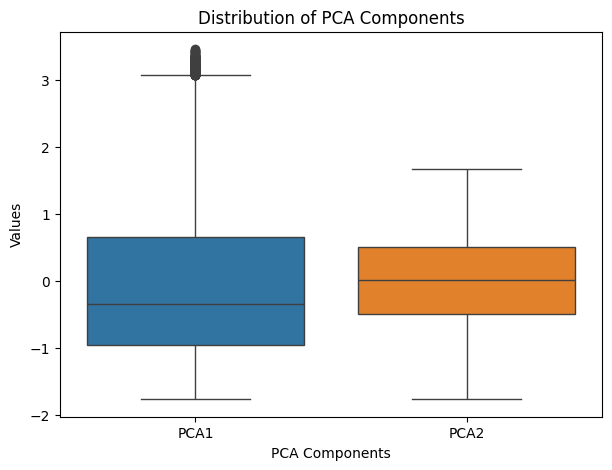

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

pca_df = pd.DataFrame(S, columns=["PCA1","PCA2"])

plt.figure(figsize=(7,5))

sns.boxplot(data=pca_df)

plt.title("Distribution of PCA Components")
plt.xlabel("PCA Components")
plt.ylabel("Values")

plt.show()